In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
data = pd.read_csv('Mall_Customers.csv')

In [3]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data = data.drop(data.columns[0] , axis = 1 )

In [5]:
print(data.isnull().sum())

Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:
from sklearn.preprocessing import StandardScaler 
X = data.iloc[:,[2,3]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Task was destroyed but it is pending!
task: <Task pending name='Task-139' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\abdou\miniconda3\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-140' coro=<Kernel.shell_main() running at C:\Users\abdou\miniconda3\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\abdou\miniconda3\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\abdou\miniconda3\Lib\site-packages\sklearn\__check_build\__init__.py:52: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  from ._check_build import check_build  # noqa: F401
Task was destroyed but it is pending!
task: <Task pending name='Task-140' coro=<Kernel.shell_main() running at C:\Users\abdou\miniconda3\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


C:\Users\abdou\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdou\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdou\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\abdou\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

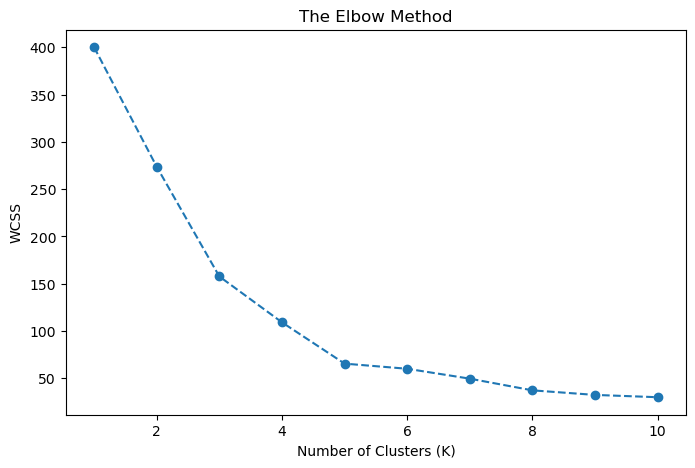

In [7]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [9]:
Kmeans = KMeans(n_clusters = 5 , init = 'k-means++' , random_state = 42 ) 
y_means = kmeans.fit_transform(X_scaled)
labels = kmeans.labels_
data['Cluster'] = labels
data.head()

C:\Users\abdou\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,8
1,Male,21,15,81,3
2,Female,20,16,6,4
3,Female,23,16,77,3
4,Female,31,17,40,8


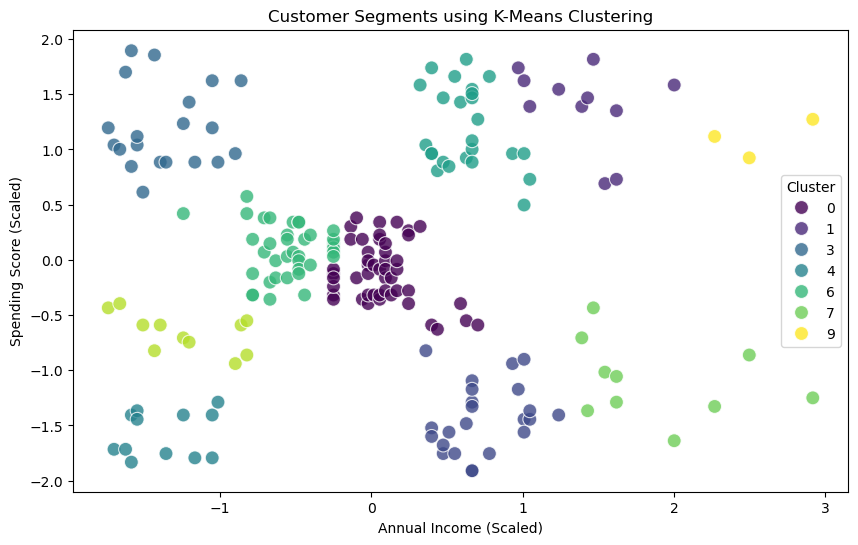

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the clusters using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_scaled[:, 0], 
    y=X_scaled[:, 1], 
    hue=labels, 
    palette='viridis', 
    s=100, 
    alpha=0.8
)

# Add title and labels
plt.title('Customer Segments using K-Means Clustering')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend(title='Cluster')
plt.show()

In [12]:
# Calculate the average values for each cluster
cluster_profiles = data.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

# Display the profile table
print(cluster_profiles)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.229167           62.583333               47.291667
1        32.636364           97.090909               86.090909
2        40.217391           79.739130               13.391304
3        24.850000           24.950000               81.000000
4        48.750000           24.583333                9.583333
5        32.760000           76.960000               80.800000
6        43.135135           45.891892               52.378378
7        41.000000          109.700000               22.000000
8        41.363636           28.181818               33.272727
9        32.333333          127.666667               78.666667
